In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data/raw_data.csv")

print("\nShape of dataset:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape of dataset:
(545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Ra

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [11]:
df['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["furnishingstatus"] = le.fit_transform(df["furnishingstatus"])

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,0


In [19]:
df['stories'].unique()

array([3, 4, 2, 1])

In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

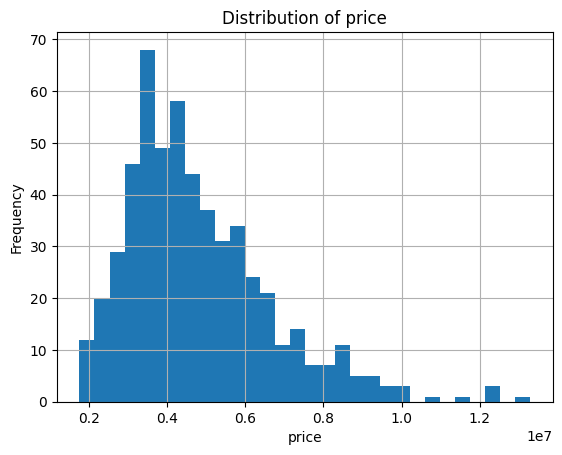

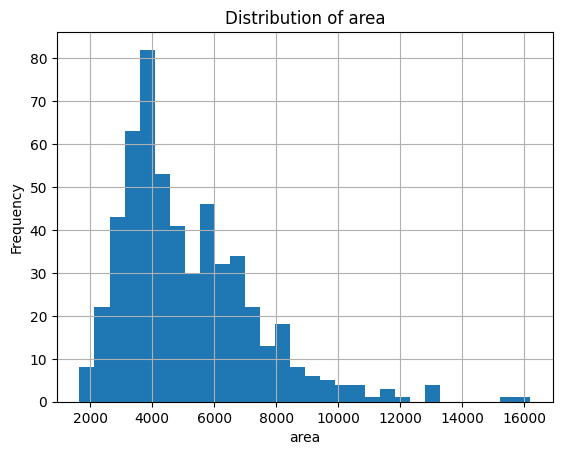

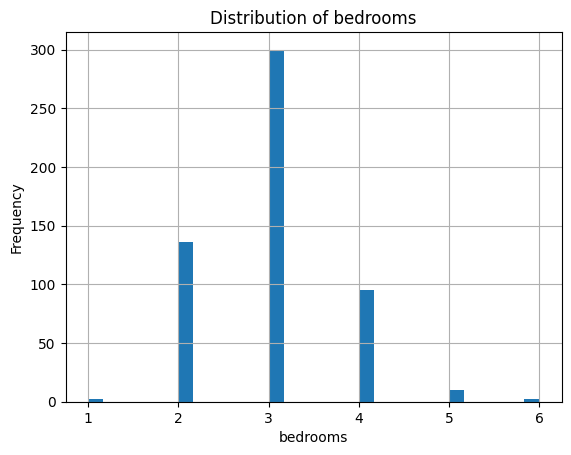

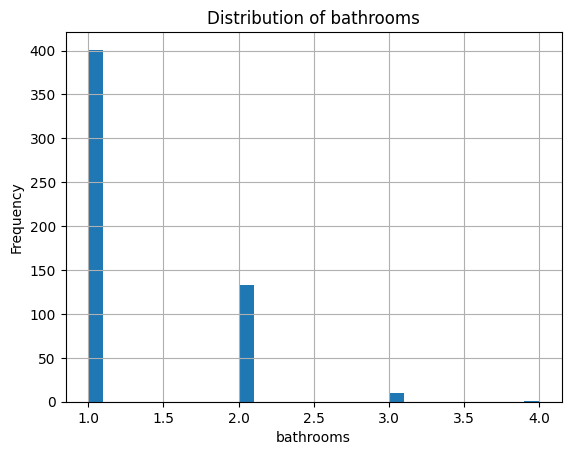

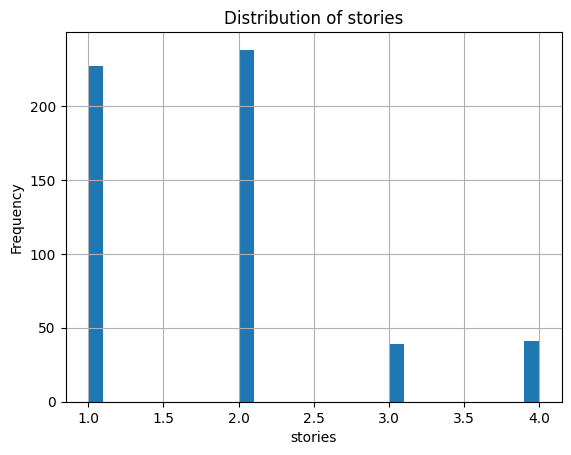

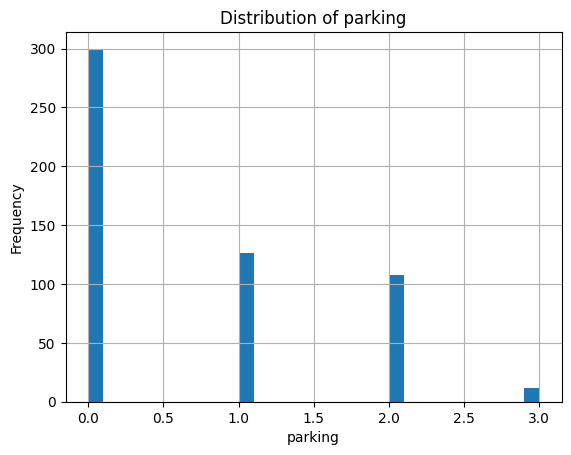

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

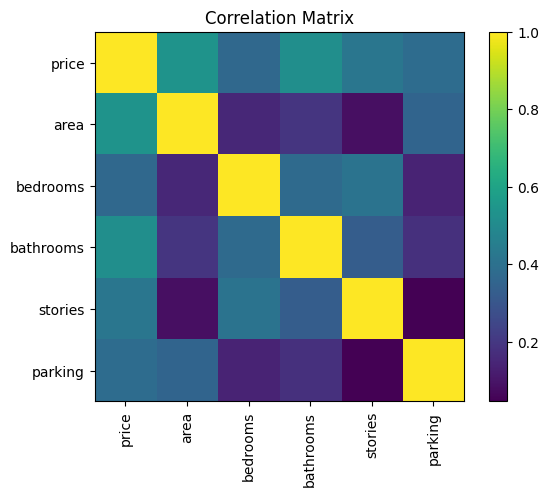

In [8]:
corr = df[num_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [9]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nAverage price by {col}:")
    print(df.groupby(col)["price"].mean())


Average price by mainroad:
mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

Average price by guestroom:
guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

Average price by basement:
basement
no     4.509966e+06
yes    5.242615e+06
Name: price, dtype: float64

Average price by hotwaterheating:
hotwaterheating
no     4.728593e+06
yes    5.559960e+06
Name: price, dtype: float64

Average price by airconditioning:
airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

Average price by prefarea:
prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64

Average price by furnishingstatus:
furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


In [21]:
process = pd.read_csv('../data/preprocessed_data.csv')
process.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,1.403419,1.421812,3,1,0,0,0,1,1.517692,1,0
1,12250000,1.757010,1.403419,5.405809,4,1,0,0,0,1,2.679409,0,0
2,12250000,2.218232,0.047278,1.421812,2,1,0,1,0,0,1.517692,1,1
3,12215000,1.083624,1.403419,1.421812,2,1,0,1,0,1,2.679409,1,0
4,11410000,1.046726,1.403419,-0.570187,2,1,1,1,0,1,1.517692,0,0
